## TCG ML PRIMER ##

**Contents:** 

Helloooooo analysts. Below is a breakdown of what you will learn through completing this primer, the fundamental Data Science - Machine Learning process, and how this will prepare you to build a model for a real client. 

---

# Table of Contents 
## 1. Problem definition
What we'll do here: clearly frame the business/data question and pick the prediction target and evaluation metric.  
What you'll learn: how to translate a real-world ask into a supervised learning task and choose a sensible metric.
1. predict coffee_name (multi-class) from transaction + time features  
2. target: coffee_name, metric: accuracy

---

## 2. Load data & missing values
What we'll do here: load the dataset and quickly summarize where values are missing so we know what to clean.  
What you'll learn: practical data loading and basic missing-value checks.
1. dataset loaded (date, datetime, cash_type, card, money, coffee_name)  
2. missing summary: card (~2.45%), coffee_name (~5.01%) — how we handled these

---

## 3. Exploratory Data Analysis (EDA)
What we'll do here: look at distributions and class balance to spot patterns and potential predictors.  
What you'll learn: how to find signal, spot class imbalance, and surface relationships that inform features.
1. inspect distributions for money, hour, day/month patterns  
2. class distribution for coffee_name (8 labels)  
3. identify features that look predictive

---

## 4. Data cleaning
What we'll do here: tidy up obvious issues — drop / fix missing labels, remove duplicates, fix types.  
What you'll learn: pragmatic cleaning choices that keep useful rows and prepare data for modeling.
1. drop / handle missing coffee_name for modeling; impute card where needed  
2. dedupe and basic sanity checks

---

## 5. Feature engineering
What we'll do here: create useful variables from datetime and encode cyclical time so the model can learn periodic patterns.  
What you'll learn: simple domain-driven feature creation and cyclic encoding for periodic data.
1. engineered hour, day_of_week, month, day_of_month, is_weekend, time_of_day  
2. cyclic encoding for hour and month (hour_sin/hour_cos, month_sin/month_cos)  
3. final feature list: money, hour, day_of_week_num, month, day_of_month, is_weekend, hour_sin, hour_cos, month_sin, month_cos, cash_type, day_of_week, time_of_day

---

## 6. Preprocessing pipeline
What we'll do here: define consistent transformations for numeric and categorical inputs using sklearn pipelines.  
What you'll learn: why pipelines and ColumnTransformer keep preprocessing reproducible and tidy.
1. numeric: median imputer + StandardScaler  
2. categorical: most frequent imputer + OneHotEncoder (handle_unknown='ignore')  
3. ColumnTransformer + Pipeline usage

---

## 7. Train / test split
What we'll do here: create a held-out test set and stratify so label proportions stay consistent.  
What you'll learn: why stratified splits matter for classification and how to pick train/test sizes.
1. stratified split on coffee_name  
2. y_train / y_test sizes and why we stratify

---

## 8. Model selection & training
What we'll do here: fit a few baseline and tree-based classifiers so we can compare performance.  
What you'll learn: how to compare different algorithms with the same pipeline and CV approach.
1. trained and compared: Logistic Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting  
2. used cross-validation (StratifiedKFold, n_splits=5) to compare mean CV accuracy

---

## 9. Cross-validation results
What we'll do here: summarize CV accuracy per model and pick promising candidates to tune.  
What you'll learn: how to read mean/std CV scores and choose models for tuning.
1. cv scores and cv_results_df showing mean/std per model  
2. per-fold scores array

---

## 10. Hyperparameter tuning
What we'll do here: run GridSearchCV on the chosen model to find better hyperparameters.  
What you'll learn: how to set up param grids, use stratified CV, and select best params by the chosen metric.
1. GridSearchCV (StratifiedKFold, scoring='accuracy') over RandomForest params (n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features)  
2. best params -> tuning_pipeline / grid_search

---

## 11. Final model & evaluation
What we'll do here: train the final pipeline with the tuned params and evaluate on the test set.  
What you'll learn: how to report final test metrics and collect predictions for analysis.
1. selected final_model (RandomForest pipeline with tuned params)  
2. test set evaluation: test_accuracy and results_df  
3. final_preds / test_preds arrays

---

## 12. Model interpretation & error analysis
What we'll do here: inspect feature importances and common mispredictions to understand model behavior.  
What you'll learn: how to extract actionable insights from importances and analyze errors to guide next steps.
1. feature importances (importance_df / importances) — money, day_of_month, month, cyclic time features are top drivers  
2. errors dataframe: inspect mispredictions, common confusions

---

## 13. Next steps / communication
What we'll do here: outline practical recommendations and deployment/validation next steps you can present to the client.  
What you'll learn: how to convert model results into clear, client-friendly actions and future experiments.
1. translate findings into plain English and a slide deck for the client  
2. suggestions: more data, class balancing strategies, alternative features (order combos, user-level history), deploy pipeline for inference

---


# STEP 0: Imports # 

*These are the imports you should need to complete this primer, you will soon see what each of these is used for and why they are necessary to create a machine learning model*


In [496]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## STEP 1: Question ##

**TODO: Come up with a meaningful data science question + pick a dataset!**

Kaggle has a bunch of open source (ie open for public use) datasets for you to choose from here: https://www.kaggle.com/datasets pick one that speaks to you. This one with information on coffee sales spoke to me : https://www.kaggle.com/datasets/ihelon/coffee-sales 

We want to answer a certain question about the data we are being given. Think about what you want to find out about the data you are looking at. If a business were to give you this data and they wanted to improve something about how they were running, what question would they ask? Depending on the dataset, the range of analysis you could do or questions you could ask is infinite, so think about what the data could actually mean. 

Example: You are given a dataset containing all of the orders (and the necessary info about them ie time place, order placed by who, order contents, nutritional info, etc) that were made at Audrey’s in Geisel during finals week, meaningful data science questions would include → 

- Does time of day affect how much caffeine people get in their drinks? 

- Are students more likely to order unhealthy foods at night? 

- Can we predict what someone will order based on the time of day? <-- For this notebook, we'll be using this question! (note: the dataset we're using in NOT from Audrey's, just a normal coffee shop) 

Once you come up with a question, start brainstorming what columns in your dataset might help you answer it!!

Data Science Question: Can we predict whether an order is high-volume based on its sales channel?

Dataset: https://www.kaggle.com/datasets/arjunmehta1992/chocolate-sales-in-20222023

## STEP 2: Loading the Dataset ## 

In [497]:
#df = pd.read_csv("/Users/nikithakerudi/Downloads/archive 2/index_1.csv")
#df.loc[df.sample(frac = 0.05).index, "coffee_name"] = np.nan
'''This dataset was a little too clean so for the purposes of teaching you guys data cleaning, this line above add some random null
values so we can see how to deal with them! (most data you encounter in the real world WILL NOT be clean)'''
df = pd.read_csv("Chocolate_Sales.csv")

## STEP 3: EDA ## 
First take a good look at your dataset: 
- What columns are there? 
- What does each column tell us? 
- Which columns relate to our problem/question? 
- Are any columns unnecessary? If so, what do we do with them? 


*Below are some common pandas methods to gain more information about your dataset without looking through each and every row/column!*

In [498]:
df.info() # note: in "coffee_name" we made sure about 5% of values are null, see how the non-null count is lower in that column! 

# (df.shape returns (3636, 6) -> 3636 total rows meaning those with 3636 non-null values are columns with no null values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order_ID         200000 non-null  object 
 1   Product          200000 non-null  object 
 2   Country          200000 non-null  object 
 3   Channel          200000 non-null  object 
 4   Salesperson      200000 non-null  object 
 5   Order_Date       199563 non-null  object 
 6   Discount_Pct     199511 non-null  float64
 7   Price_per_Box    199543 non-null  float64
 8   Marketing_Spend  199539 non-null  float64
 9   Boxes_Shipped    200000 non-null  int64  
 10  Amount           200000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 16.8+ MB


In [499]:
df.describe()

,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped
count,199511.000000,199543.000000,199539.000000,200000.000000
mean,13.107457,5.911507,95.450141,139.584105
std,6.374477,4.954976,66.243760,118.665393
min,0.000000,2.040000,4.300000,-1642.000000
25%,8.300000,2.950000,52.270000,67.000000
50%,12.600000,3.280000,78.850000,113.000000
75%,17.500000,4.570000,118.710000,180.000000
max,38.300000,21.650000,798.222443,3811.000000


In [500]:
df.columns # returns columns as an array


Index(['Order_ID', 'Product', 'Country', 'Channel', 'Salesperson',
       'Order_Date', 'Discount_Pct', 'Price_per_Box', 'Marketing_Spend',
       'Boxes_Shipped', 'Amount'],
      dtype='object')

In [501]:
df.loc[0][0] #date column shows date as a string 

/var/folders/bj/_chbshms4bd63hgqm8v__pk40000gn/T/ipykernel_20660/2890983164.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.loc[0][0] #date column shows date as a string


'ORD-069833'

In [502]:
df.loc[0][1] #datetime column can easily be made into -> datetime object 

/var/folders/bj/_chbshms4bd63hgqm8v__pk40000gn/T/ipykernel_20660/1228516380.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df.loc[0][1] #datetime column can easily be made into -> datetime object


'Truffle Gift Box'

Here we can see our columns are 'date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name'. Going back to our original question of : "Can we predict what someone will order based on the time of day?" what columns do you think are relevant here? 

Answer: datetime and coffe_name

### Lets explore a little more about this data ### 

Specifically let's look at: 

1. How much of each coffee drink is sold? 
2. Are some values missing? If so, where? What do we do with them? 
3. What types of values are we seeing in each column? 

Below are some useful EDA techniques: 

In [503]:
print(df.head()) # shows first 5 rows of the dataset


     Order_ID            Product    Country Channel    Salesperson  \
0  ORD-069833   Truffle Gift Box  Australia  Retail    Arjun Mehta   
1  ORD-090726       85% Dark Bar  Australia  Retail    Arjun Mehta   
2  ORD-042159       70% Dark Bar      Japan  Retail  Hannah Müller   
3  ORD-197166  Hazelnut Milk Bar    Germany  Retail    Arjun Mehta   
4  ORD-112162  Almond Crunch Bar  Australia  Retail      Yuki Sato   

   Order_Date  Discount_Pct  Price_per_Box  Marketing_Spend  Boxes_Shipped  \
0  2022-12-11           3.5          13.72           202.03             71   
1  2023-03-14           9.4           3.30            55.18             84   
2  2023-12-21           4.9          18.21            60.65             35   
3  2023-12-18          15.0           2.66            52.00             92   
4  2023-08-18           4.4           2.75           187.44            214   

   Amount  
0  912.31  
1  245.91  
2   583.7  
3  211.27  
4  549.69  


In [504]:
print(df.sample(5)) # shows 5 random rows of the dataset (useful for getting a quick look at the data)


          Order_ID               Product    Country    Channel  \
130868  ORD-101851          70% Dark Bar     Brazil     Online   
76761   ORD-132175      Truffle Gift Box  Australia     Retail   
162831  ORD-145620      Milk Classic Bar      India     Online   
109439  ORD-001200          70% Dark Bar  Australia     Retail   
130674  ORD-122111  Mixed Assortment Box  Australia  Wholesale   

            Salesperson  Order_Date  Discount_Pct  Price_per_Box  \
130868  Rafael Oliveira  2022-01-04          17.1           3.88   
76761       Arjun Mehta  2023-05-14          16.8           2.70   
162831      Arjun Mehta  2023-07-07           9.4           2.76   
109439     Emily Clarke  04/10/2023          18.2           4.13   
130674     Priya Sharma  2022-07-16          13.3           3.18   

        Marketing_Spend  Boxes_Shipped  Amount  
130868           160.37            233  770.14  
76761            167.94            131  306.87  
162831           114.19             84  202.36 

In [505]:
print(df.isnull().sum()) # shows number of null values in each column (useful for data cleaning)


Order_ID             0
Product              0
Country              0
Channel              0
Salesperson          0
Order_Date         437
Discount_Pct       489
Price_per_Box      457
Marketing_Spend    461
Boxes_Shipped        0
Amount               0
dtype: int64


In [506]:
print(df.nunique()) #shows number of unique values in each column (useful for understanding categorical variables)


Order_ID           200000
Product                12
Country                 5
Channel                 3
Salesperson            25
Order_Date           2000
Discount_Pct         2517
Price_per_Box        1381
Marketing_Spend     27319
Boxes_Shipped        1521
Amount              85605
dtype: int64


In [507]:
#print(df["coffee_name"].value_counts()) # shows count of each unique value in the "coffee_name" column (useful for understanding distribution of categorical variable)
print(df["Boxes_Shipped"].describe())

count    200000.000000
mean        139.584105
std         118.665393
min       -1642.000000
25%          67.000000
50%         113.000000
75%         180.000000
max        3811.000000
Name: Boxes_Shipped, dtype: float64


### Missing Values 

First, let's take a look at our missing values and see what we should do with them

In [508]:
# see what values are mising in each column: 
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})
missing_summary

,missing_count,missing_percent
Order_ID,0,0.00
Product,0,0.00
Country,0,0.00
Channel,0,0.00
Salesperson,0,0.00
Order_Date,437,0.22
Discount_Pct,489,0.24
Price_per_Box,457,0.23
Marketing_Spend,461,0.23
Boxes_Shipped,0,0.00


In [509]:
# see how many unique values are in each column: 
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Order_ID: 200000 unique values
Product: 12 unique values
Country: 5 unique values
Channel: 3 unique values
Salesperson: 25 unique values
Order_Date: 2000 unique values
Discount_Pct: 2517 unique values
Price_per_Box: 1381 unique values
Marketing_Spend: 27319 unique values
Boxes_Shipped: 1521 unique values
Amount: 85605 unique values


Let's quickly visualize what the distribution of our data looks like. This step is important for you as a data scienctist to see the balance or imbalance of each categorical variable. If one drink is ordered 90% of the time, we want to make sure our model doesn't just learn that and predict that drink over and over. In more formal terms this helps us identify any **class imbalances**. 

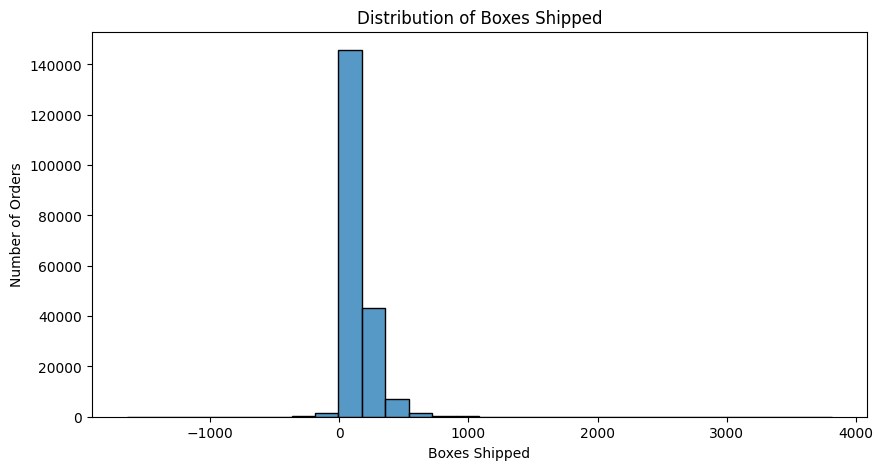

In [510]:
# Target distribution: which drinks are most common?
#plt.figure(figsize=(10, 5))
#sns.countplot(data=df, y="coffee_name", order=df["coffee_name"].value_counts().index)
#plt.title("Distribution of Coffee Orders")
#plt.xlabel("Number of Orders")
#plt.ylabel("Coffee Name")
#plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Boxes_Shipped", bins=30)
plt.title("Distribution of Boxes Shipped")
plt.xlabel("Boxes Shipped")
plt.ylabel("Number of Orders")

plt.show()

# STEP 4: DATA CLEANING / PREPROCESSING

Data Cleaning makes the dataset more consistent and structured in a way such that the model can easily use it to make predictions. This is where we handle missing values, duplicates, inconsistent data types, and extreme values. 

1. Duplicates 
2. Data Types
3. Extreme Values 
4. Missing Values 

Pro tip: If we don't want to risk tarnishing the original dataset or if we want to rexplore something from a column we may have already dropped, it's best to make a cleaned copy of your DataFrame. 

In [511]:
cleaned_df = df.copy()
print("Original Shape:", cleaned_df.shape)
print("Duplicate Rows:", cleaned_df.duplicated().sum())

#let's make sure to drop duplicates if any so the model doesn't see the same data twice and get confused 
cleaned_df = cleaned_df.drop_duplicates()
print("New Shape (after dropping duplicates):", cleaned_df.shape)

Original Shape: (200000, 11)
Duplicate Rows: 0
New Shape (after dropping duplicates): (200000, 11)


In [512]:
#convert date and datetime cols --> actual datetime objects (not strings)
#cleaned_df["date"] = pd.to_datetime(cleaned_df["date"])
#cleaned_df["datetime"] = pd.to_datetime(cleaned_df["datetime"])
#cleaned_df[['date', 'datetime']].head()

cleaned_df["Order_Date"] = pd.to_datetime(cleaned_df["Order_Date"], format="mixed")
cleaned_df[["Order_Date"]].head()

,Order_Date
0,2022-12-11
1,2023-03-14
2,2023-12-21
3,2023-12-18
4,2023-08-18


In [513]:
#check for any impossible/extreme values 
#for example for the money column a negative value would be impossible 
#print("Rows with missing datetime: ", cleaned_df["datetime"].isnull().sum())
#print("Rows with missing date: ", cleaned_df["date"].isnull().sum())
#print("Rows with negative money: ", (cleaned_df['money'] <= 0).sum())

# we want to keep only rows with valid datetime and positive money 
#cleaned_df = cleaned_df.dropna(subset=["datetime", "date"])
#cleaned_df = cleaned_df[cleaned_df['money'] > 0]
#cleaned_df.shape

print("Rows with missing Channel:", cleaned_df["Channel"].isnull().sum())
print("Rows with missing Boxes_Shipped:", cleaned_df["Boxes_Shipped"].isnull().sum())
print("Rows with negative Boxes_Shipped:", (cleaned_df["Boxes_Shipped"] < 0).sum())

cleaned_df = cleaned_df.dropna(subset=["Channel", "Boxes_Shipped"])
cleaned_df = cleaned_df[cleaned_df["Boxes_Shipped"] >= 0]

cleaned_df.shape

Rows with missing Channel: 0
Rows with missing Boxes_Shipped: 0
Rows with negative Boxes_Shipped: 1956


(198044, 11)

In [514]:
#for our columns with strings as values, make sure the format is standardized (ie latte vs Latte --> standardize those)
#for col in ['cash_type', 'coffee_name']:
#   cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.lower()

#cleaned_df[['cash_type', 'coffee_name']].head()

for col in ["Product", "Country", "Channel", "Salesperson"]:
    cleaned_df[col] = (
        cleaned_df[col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

cleaned_df[["Product", "Country", "Channel", "Salesperson"]].head()

,Product,Country,Channel,Salesperson
0,truffle gift box,australia,retail,arjun mehta
1,85% dark bar,australia,retail,arjun mehta
2,70% dark bar,japan,retail,hannah müller
3,hazelnut milk bar,germany,retail,arjun mehta
4,almond crunch bar,australia,retail,yuki sato


# STEP 5: FEATURE ENGINEERING 
When we say "feature engineering", features are our variables (ie. our columns) and engineering those means transforming them in a way such that we can derive patterns from the data. What that entails in the scope of machine learning is that the input variables for the model should be formatted in order for the model to understand them the way a human does, so we are converting our columns to useful features by doing that. 

In [515]:
# model_df = cleaned_df.copy()

# model_df["hour"] = model_df["datetime"].dt.hour
# model_df["day_of_week"] = model_df["datetime"].dt.day_name()
# model_df["day_of_week_num"] = model_df["datetime"].dt.dayofweek
# model_df["month"] = model_df["datetime"].dt.month
# model_df["day_of_month"] = model_df["datetime"].dt.day
# model_df["is_weekend"] = (model_df["datetime"].dt.dayofweek >= 5).astype(int)

# def get_time_of_day(hour):
#     if 5 <= hour < 12:
#         return "morning"
#     elif 12 <= hour < 17:
#         return "afternoon"
#     elif 17 <= hour < 21:
#         return "evening"
#     else:
#         return "night"

# model_df["time_of_day"] = model_df["hour"].apply(get_time_of_day)

# # cyclical time features: helps model understand that 23:00 and 0:00 are close
# model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
# model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)

# model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
# model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

# model_df.head()
model_df = cleaned_df.copy()

median_boxes = model_df["Boxes_Shipped"].median()
model_df["High_Volume"] = (model_df["Boxes_Shipped"] > median_boxes).astype(int)

model_df["year"] = model_df["Order_Date"].dt.year
model_df["month"] = model_df["Order_Date"].dt.month
model_df["quarter"] = model_df["Order_Date"].dt.quarter

model_df.head()

,Order_ID,Product,Country,Channel,Salesperson,Order_Date,Discount_Pct,Price_per_Box,Marketing_Spend,Boxes_Shipped,Amount,High_Volume,year,month,quarter
0,ORD-069833,truffle gift box,australia,retail,arjun mehta,2022-12-11,3.5,13.72,202.03,71,912.31,0,2022.0,12.0,4.0
1,ORD-090726,85% dark bar,australia,retail,arjun mehta,2023-03-14,9.4,3.30,55.18,84,245.91,0,2023.0,3.0,1.0
2,ORD-042159,70% dark bar,japan,retail,hannah müller,2023-12-21,4.9,18.21,60.65,35,583.7,0,2023.0,12.0,4.0
3,ORD-197166,hazelnut milk bar,germany,retail,arjun mehta,2023-12-18,15.0,2.66,52.00,92,211.27,0,2023.0,12.0,4.0
4,ORD-112162,almond crunch bar,australia,retail,yuki sato,2023-08-18,4.4,2.75,187.44,214,549.69,1,2023.0,8.0,3.0


Let's quickly visualize how the new features we created relate to the target variable (coffee_name) to see if they might be useful for our model:

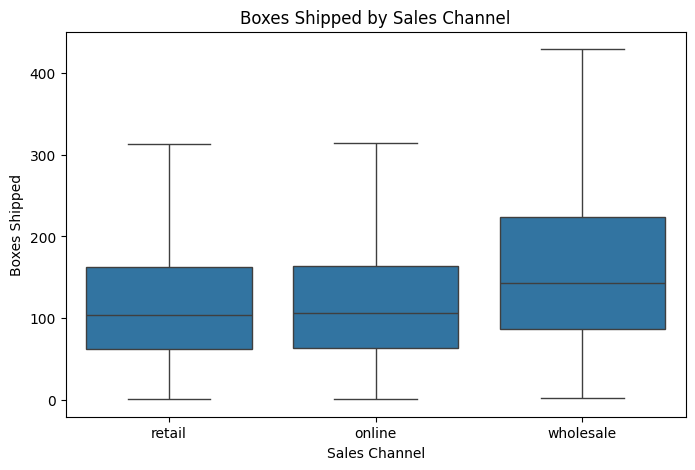

In [516]:
# plt.figure(figsize=(10, 5))
# sns.countplot(data=model_df, x="time_of_day", hue="coffee_name")
# plt.title("Coffee Orders by Time of Day")
# plt.xlabel("Time of Day")
# plt.ylabel("Number of Orders")
# plt.xticks(rotation=45)
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
# plt.show()
plt.figure(figsize=(8,5))

sns.boxplot(data=model_df, x="Channel", y="Boxes_Shipped", showfliers=False)

plt.title("Boxes Shipped by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Boxes Shipped")

plt.show()


# STEP 5.5: FEATURE SELECTION 
Here, our main goal is to just choose the columns that the model will be using. We want to avoid using columns that are overly specific like unique identifier columns, columns that are unavailable at the time of prediction, or columns that are too similar to the actual target. 

In [517]:
# numeric_features = [
#     "money",
#     "hour",
#     "day_of_week_num",
#     "month",
#     "day_of_month",
#     "is_weekend",
#     "hour_sin",
#     "hour_cos",
#     "month_sin",
#     "month_cos"
# ]

# categorical_features = [
#     "cash_type",
#     "day_of_week",
#     "time_of_day"
# ]

# features = numeric_features + categorical_features

# X = model_df[features]
# y = model_df[target_col]

# print("Feature columns:", features)
# print("Target column:", target_col)
# print("X shape:", X.shape)
# print("y shape:", y.shape)

# X.head()
numeric_features = [
    "Discount_Pct",
    "Price_per_Box",
    "Marketing_Spend",
    "year",
    "month",
    "quarter"
]

categorical_features = [
    "Channel",
    "Country",
    "Product"
]
features = numeric_features + categorical_features

target_col = "High_Volume"

X = model_df[features]
y = model_df[target_col]

print("Feature columns:", features)
print("Target column:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Feature columns: ['Discount_Pct', 'Price_per_Box', 'Marketing_Spend', 'year', 'month', 'quarter', 'Channel', 'Country', 'Product']
Target column: High_Volume
X shape: (198044, 9)
y shape: (198044,)


,Discount_Pct,Price_per_Box,Marketing_Spend,year,month,quarter,Channel,Country,Product
0,3.5,13.72,202.03,2022.0,12.0,4.0,retail,australia,truffle gift box
1,9.4,3.30,55.18,2023.0,3.0,1.0,retail,australia,85% dark bar
2,4.9,18.21,60.65,2023.0,12.0,4.0,retail,japan,70% dark bar
3,15.0,2.66,52.00,2023.0,12.0,4.0,retail,germany,hazelnut milk bar
4,4.4,2.75,187.44,2023.0,8.0,3.0,retail,australia,almond crunch bar


# STEP 6: TRAIN / TEST SPLIT 
Our model needs to be trained on data in order to learn the patterns that exist within it and once we've created our model, we test it with examples of data that it hasn't seen before. In order to do this, we must split our data into "training" and "testing" data, where the training set teaches the model and the testing set estimates how the model will perform on real world / new data. The code for doing this is pretty standardized, a good practice is the 80/20 split (train/test). (Note: don't worry too much about random state, this is something we can leave to abstraction for building ML models)

In [518]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training rows: 158435
Testing rows: 39609
Training target distribution:
High_Volume
0    0.5
1    0.5
Name: proportion, dtype: float64


# STEP 7: MODEL SELECTION 
We will break this step down a little further into the following: 
1. Preprocessing Pipeline 
2. Establishing a Baseline Model 
3. Model Selection and Training 

### Why does preprocessing matter? 

Raw data is almost never ready for a model to learn from, thus not ready for actual machine learning, which requires numbers. Real datasets often contain one or many of the following which make it unusable to the model: 

- missing values
- text categories
- columns on different scales 
- messy labels 
- irrelevant columns 
- dates 

Preprocessing is the step where we turn the real world data that you'd be given into a format that a machine can more easily read and understand. Here, you'll see we use a 'ColumnTransformer' because different column types need different treatments. 

### What is a pipeline and why does it matter? 

A pipeline essentially means chaining multiple steps together, instead of doing them manually. Here we can put the following into one object: 

1. cleaning data 
2. encoding categories 
3. scaling numbers 
4. training the model

## Preprocessing Pipeline 

We know that machine learning models rely on inputs being quantitative, thus this step of creating a preprocessing pipeline handles both categorial and numeric features. 

1. Numeric features --> fill any missing values left and scale them 
2. Categorical features --> fill any missing values and one-hot encode them 

Question: We know that models need numeric variables so turning categorical features into those is what we call one-hot encoding. Identify a few examples of what columns could be one-hot encoded and HOW to one-hot encode different types of data. 

ANSWER: Categorical columns such as cash_type, day_of_week, and time_of_day should be one-hot encoded because they represent categories rather than numerical values. One-hot encoding creates a new binary column for each category. For example, the cash_type column containing card and cash would become two columns (cash_type_card and cash_type_cash), where a value of 1 indicates the category is present and 0 otherwise.

Here, we want to fit preprocessing on the training data only, then apply it to the testing data after. 

**Important Key Terms to Know:** 

imputing: filling missing values with other values in the data (ie filling nan with mean/mode/median)

StandardScalar() --> preprocessing tool from Pipeline to scale numeric variables 

ColumnTransformer() --> does exactly what it sounds like, transforms columns 

OneHotEncoder() --> same thing, one-hot encodes columns 

In [519]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Discount_Pct', 'Price_per_Box',
                                  'Marketing_Spend', 'year', 'month',
                                  'quarter']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Channel', 'Country', 'Product'])])

## Baseline Model 

Before we train a real model, we want to build a simple baseline model to get us started and then we can tweak each feature weight, hyperparameters, and other metrics accordingly to improve our models accuracy. A baseline model should ideally answer the question of "How well could we do with a simple strategy?". This model will essentially always predict the most common drink (making it's accuracy the frequency of that drink in the data). 


In [520]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

print("Baseline accuracy:", round(baseline_accuracy, 3))
print("Most common class:", "High Volume" if y_train.value_counts().idxmax() == 1 else "Not High Volume")

Baseline accuracy: 0.5
Most common class: Not High Volume



## Model Selection and Training 

Here, we will explore three different models and compare their performance to see which one is the best suited for our data. These are three of the most commonly used and simplest machine learning models. 

1. Logistic Regression: simple, interepretable classification model 
2. Decision Tree: rule-based model that can capture more non linear patterns 
3. Random Forest: ensemble of many decision trees, usually stronger but less interpretable 

### What is a class imabalance? 

Sometimes we'll see one category appear far more than others (ie. if 50% of all drinks ordered are a latte and the other 50% is split amongst the other drinks). A lazy model would predict the class with the highest appearence everytime, making it predict based on chance yeilding higher accuracy in training but will yeild lower accuracy when tested on unseen data! (Hint: DON'T DO THIS) 

'class_weight="balanced"' --> tells model to pay more attention to less common classes 

In [521]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=8,
        min_samples_leaf=5
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        max_depth=None,
        min_samples_leaf=2
    ),
    
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        min_samples_leaf=2
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    
    trained_pipelines[name] = pipe
    results.append({"model": name, "test_accuracy": acc})

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df

,model,test_accuracy
5,Hist Gradient Boosting,0.892903
2,Random Forest,0.888535
4,Gradient Boosting,0.884420
3,Extra Trees,0.880280
0,Logistic Regression,0.875331
1,Decision Tree,0.842738


### Why compare multiple models? 

There is no sinlge best model for each dataset, different models typically learn different patterns in different ways:

Logistic Regression --> learns most linear relationships 
Decision Trees --> learn rule-based splits 
Random Forests --> combine many trees 
Extra Trees --> more randomness 
GRadient Boosting --> builds trees sequentially to fix previous mistakes 

In [522]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_pipelines[best_model_name]

print("Best model:", best_model_name)

Best model: Hist Gradient Boosting


# STEP 8: MODEL EVALUATION 
This is where we see how well the model performs and where exactly it is failing. Accuracy is a good metric to give us a summary number, but the classification report and confusion matrix show performance by class which is helpful for our non-numeric columns especially. 

In [523]:
test_preds = best_model.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, test_preds), 3))
print("Classification report:")
print(classification_report(y_test, test_preds))

Test accuracy: 0.893
Classification report:
              precision    recall  f1-score   support

           0       0.89      0.90      0.89     19824
           1       0.90      0.89      0.89     19785

    accuracy                           0.89     39609
   macro avg       0.89      0.89      0.89     39609
weighted avg       0.89      0.89      0.89     39609



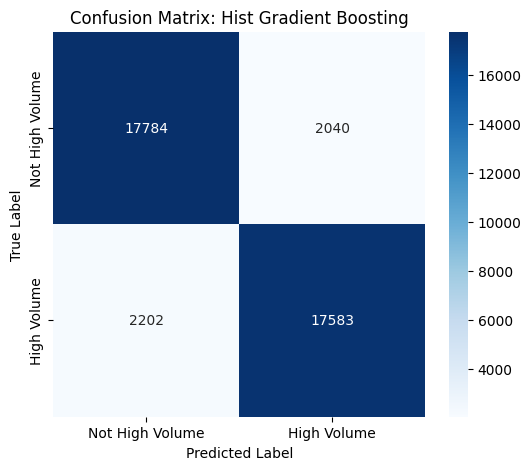

In [524]:
# labels = sorted(y_test.unique())
# cm = confusion_matrix(y_test, test_preds, labels=labels)

# plt.figure(figsize=(10, 7))
# sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
# plt.title(f"Confusion Matrix: {best_model_name}")
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.show()

labels = [0, 1]
label_names = ["Not High Volume", "High Volume"]

cm = confusion_matrix(y_test, test_preds, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names, cmap="Blues")

plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Cross-Validation

Cross-Validation gives us a more reliable estimate by training and testing the model several times on different splits of the data. 

5-fold cross-validation:
1. split data into 5 parts 
2. train on 4 parts 
3. test on remaining part 
4. repeat 5 times 
5. average the scores 

### Why one train/test split isn't enough: 

One train/test split can be lucky or unlucky. Cross-validation trains and evaluates the model multiple times on different splits to get a more stable performance estimate.

In [525]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    
    cv_results.append({
        "model": name,
        "mean_cv_accuracy": scores.mean(),
        "std_cv_accuracy": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_cv_accuracy", ascending=False)
cv_results_df

,model,mean_cv_accuracy,std_cv_accuracy
5,Hist Gradient Boosting,0.891984,0.002855
2,Random Forest,0.887262,0.002289
4,Gradient Boosting,0.882425,0.002093
3,Extra Trees,0.879178,0.001926
0,Logistic Regression,0.873614,0.003204
1,Decision Tree,0.842237,0.001492


# Hyperparameter Tuning

A model has two types of settings: 
1. Parameters: these are learned from the data ie. the splits inside a decision tree 

2. Hyperparameters: these settings we choose before training. Grid search tries combinations of settings and uses cross-validation to find the best one.

Examples: 
- number of trees 
- max tree depth 
- minimum samples per leaf 
- max number of features considered at each split 

In [526]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))
])

# param_grid = {
#     "model__n_estimators": [300, 500, 800],
#     "model__max_depth": [None, 5, 10, 20],
#     "model__min_samples_split": [2, 5, 10],
#     "model__min_samples_leaf": [1, 2, 4],
#     "model__max_features": ["sqrt", "log2", None]
# }

param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 3))

final_model = grid_search.best_estimator_

/Users/alyssagong/.pyenv/versions/3.10.4/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV accuracy: 0.887


In [527]:
final_preds = final_model.predict(X_test)

print("Final tuned model test accuracy:", round(accuracy_score(y_test, final_preds), 3))
print()
print("Final tuned model classification report:")
# print(classification_report(y_test, final_preds))
print(classification_report(y_test, final_preds, target_names=["Not High Volume", "High Volume"]))

Final tuned model test accuracy: 0.891

Final tuned model classification report:
                 precision    recall  f1-score   support

Not High Volume       0.89      0.89      0.89     19824
    High Volume       0.89      0.89      0.89     19785

       accuracy                           0.89     39609
      macro avg       0.89      0.89      0.89     39609
   weighted avg       0.89      0.89      0.89     39609



## Model Interpretability 

A model's accuracy tells us how well it performs, feature importance helps us understand why. For tree-based models, feature importance estimates which variables were most useful for making predictions. 

In [528]:
#let's get our feature names from the preprocessor and coefficients from 
#the logistic regression model to see which features are most 
# important for predicting each drink

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
1,num__Price_per_Box,0.368419
2,num__Marketing_Spend,0.194286
0,num__Discount_Pct,0.079364
10,cat__Country_brazil,0.062678
21,cat__Product_mixed assortment box,0.057332
4,num__month,0.036879
8,cat__Channel_wholesale,0.028175
24,cat__Product_truffle gift box,0.023935
14,cat__Product_70% dark bar,0.017097
5,num__quarter,0.015915


## Error Analysis 

Accuracy tells us how often the model is correct while error analysis tells us where the model is going wrong. This one is the most important in real world DSML skills because improving a model can only happen when you identify and combat it's errors! 

In [529]:
errors = X_test.copy()
errors["actual"] = y_test.values
errors["predicted"] = final_preds

errors = errors[errors["actual"] != errors["predicted"]]
errors.head(20)

,Discount_Pct,Price_per_Box,Marketing_Spend,year,month,quarter,Channel,Country,Product,actual,predicted
26233,20.00,3.94,67.23,2023.0,8.0,3.0,wholesale,australia,70% dark bar,0,1
155904,23.10,2.79,90.86,2022.0,3.0,1.0,online,australia,70% dark bar,0,1
108080,3.80,12.88,178.76,2023.0,1.0,1.0,online,brazil,mixed assortment box,0,1
44498,6.80,2.81,88.26,2022.0,8.0,3.0,wholesale,japan,milk classic bar,0,1
142409,11.40,3.26,115.09,2022.0,3.0,1.0,retail,japan,70% dark bar,1,0
85677,19.00,3.47,52.93,2023.0,8.0,3.0,retail,brazil,salted caramel bar,0,1
97900,4.66,3.43,120.32,2022.0,7.0,3.0,wholesale,australia,70% dark bar,0,1
47433,14.90,18.16,112.48,2022.0,2.0,1.0,wholesale,japan,mixed assortment box,1,0
148493,13.20,2.34,41.05,2023.0,3.0,1.0,retail,brazil,pralines gift box,0,1
119347,2.60,2.90,123.85,2023.0,12.0,4.0,retail,brazil,70% dark bar,0,1


## Congrats! 

By this point you would have completed the entire ML process end-to-end! At this point in your project, you client would be looking for you to showcase all the insights this model provided about the data and concurrently how the business should respond, adjust, or pivot based on these insights. Take this huge win of building a model and turn it into another question --> "How would a company or business benefit from a model like this?" 

If the model predicts an order is likely to be high-volume, the company can prepare enough chocolate products ahead of time and reduce the risk of stock shortages.